In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from icecube import icetray, dataio, phys_services                                                                        
from icecube import dataclasses  
from matplotlib.colors import LogNorm
from scipy.stats import ks_2samp
import tables
import pandas as pd

In [3]:
df = pd.read_hdf('../../dataset_complete/BDT/BDT_all.h5', key='data')

beta1 = df['Beta1Reco']
ang_median = df['ang_median']

energy = df['RecoEnergy']
label = df['Label']

boolCC = (label == 1)
boolNC = (label == 0)

beta1_CC = beta1[boolCC]
beta1_NC = beta1[boolNC]

In [4]:
boolean = (beta1 >= 0) & (beta1 <= 0.0002) & (ang_median >= 0.62) & (ang_median <= 0.77)

(array([ 897.40289862, 3134.59040645, 5081.06993304, 6269.18081291,
        6825.3178205 , 6863.23625284, 6863.23625284, 6913.79416262,
        7545.76803489, 7103.3863243 , 6800.03886561, 7040.18893707,
        7330.89691832, 7697.44176423, 7659.5233319 , 7065.46789196,
        7672.16280934, 7280.33900854, 7646.88385445, 7116.02580175,
        6294.4597678 , 6597.80722649, 6673.64409116, 6484.05192948,
        6610.44670393, 6736.84147838, 6041.67021889, 6370.29663247,
        6142.78603845, 5776.24119254, 5776.24119254, 5675.12537297,
        5864.71753465, 5864.71753465, 5877.3570121 , 5675.12537297,
        5169.54627516, 5700.40432786, 5561.37007596, 5068.4304556 ,
        5194.82523005, 5498.17268874, 5106.34888793, 5321.2200045 ,
        5611.92798575, 5422.33582407, 5017.87254581, 5017.87254581,
        5005.23306837, 5384.41739173, 4853.55933902, 4752.44351946,
        4866.19881647, 4562.85135778, 4866.19881647, 4613.40926756,
        4929.3962037 , 4866.19881647, 4449.09606

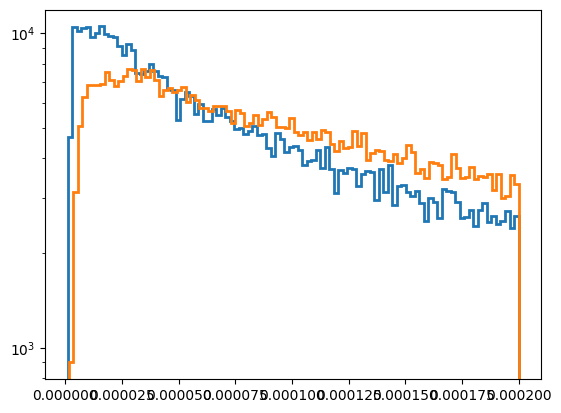

In [5]:
plt.hist(beta1[boolCC][boolean], bins=100, histtype='step', density=True, log=True, lw=2)
plt.hist(beta1[boolNC][boolean], bins=100, histtype='step', density=True, log=True, lw=2)

In [6]:
precision = []
recall = []

y_true = label#[boolean]
y_prob = beta1#[boolean]

y_prob1 = ang_median

uthreshold = 0.0002#0.002
lthreshold = 0.0

#y_pred = np.where((y_prob <= threshold), 1, 0)
y_pred = np.where((y_prob <= uthreshold)&(y_prob >= lthreshold)&(y_prob1 >= 0.62)&(y_prob1 <= 0.77), 1, 0)
                  
fp = np.sum((y_pred == 1) & (y_true == 0))
tp = np.sum((y_pred == 1) & (y_true == 1))

fn = np.sum((y_pred == 0) & (y_true == 1))
tn = np.sum((y_pred == 0) & (y_true == 0))

precision.append(tp / (tp + fp) if (tp + fp) > 0 else 1.0)
recall.append(tp / (tp + fn) if (tp + fn) > 0 else 0.0)

baseline = len(beta1_CC)/(len(beta1_CC) + len(beta1_NC))
print(baseline)

precision = np.array(precision)
recall = np.array(recall)

# Sort by FPR in case they're not
sorted_indices = np.argsort(recall)
precision = precision[sorted_indices]
recall = recall[sorted_indices]

# Compute AUC using trapezoidal rule
auc_pr = np.trapz(precision, recall)
print(f"AUC = {auc_pr:.2f}")

0.2446858570214889
AUC = 0.00


In [7]:
tp, fn

(30234, 426836)

Text(0, 0.5, 'Precision')

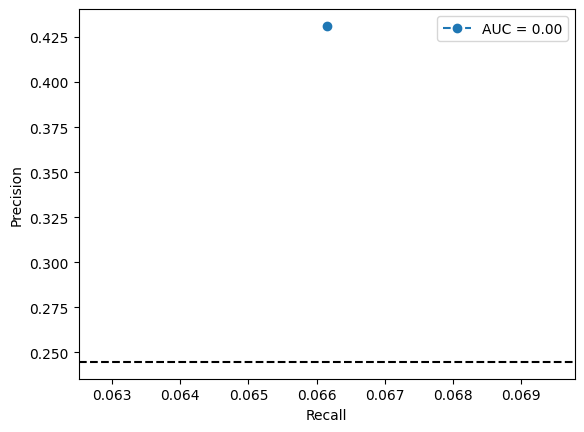

In [8]:
plt.plot(recall[precision<1], precision[precision<1], 'o--', label = f'AUC = {auc_pr:.2f}')
plt.axhline(y=baseline, c='k', ls='--')
plt.legend()
plt.xlabel('Recall')
plt.ylabel('Precision')

In [12]:
fpr = []
tpr = []

y_true = label#[boolean]
y_prob = beta1#[boolean]

y_prob1 = ang_median#[boolean]

uthreshold = 0.0002#0.002
lthreshold = 0.0

#y_pred = np.where((y_prob <= threshold), 1, 0)
y_pred = np.where((y_prob <= uthreshold)&(y_prob >= lthreshold)&(y_prob1 >= 0.60)&(y_prob1 <= 0.75), 1, 0)
                  
fp = np.sum((y_pred == 1) & (y_true == 0))
tp = np.sum((y_pred == 1) & (y_true == 1))

fn = np.sum((y_pred == 0) & (y_true == 1))
tn = np.sum((y_pred == 0) & (y_true == 0))

fpr.append(fp / (fp + tn))
tpr.append(tp / (tp + fn))

fpr = np.array(fpr)
tpr = np.array(tpr)

# Sort by FPR in case they're not
sorted_indices = np.argsort(fpr)
fpr = fpr[sorted_indices]
tpr = tpr[sorted_indices]

# Compute AUC using trapezoidal rule
auc = np.trapz(tpr, fpr)
print(f"AUC = {auc:.2f}")

AUC = 0.00


Text(0, 0.5, 'True Positive Rate')

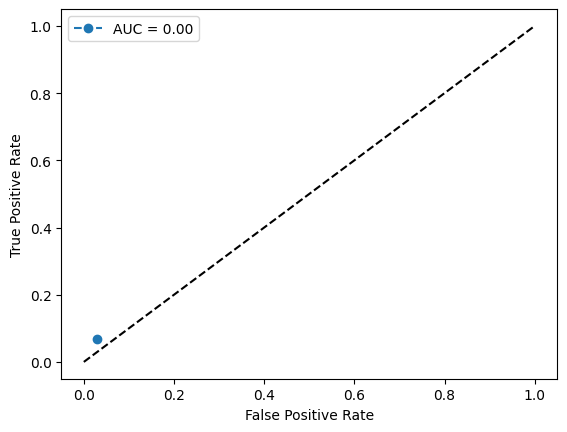

In [13]:
plt.plot(fpr, tpr, 'o--', label = f'AUC = {auc:.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.legend()
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate') 

In [14]:
label[boolean][label == 1]

67         1.0
77         1.0
214        1.0
362        1.0
432        1.0
          ... 
1867740    1.0
1867797    1.0
1867857    1.0
1867917    1.0
1867969    1.0
Name: Label, Length: 30234, dtype: float64

(array([1.37977307e-03, 2.75954615e-03, 2.75954615e-03, 6.20897883e-03,
        3.44943268e-03, 4.82920576e-03, 2.75954615e-03, 5.51909229e-03,
        1.37977307e-03, 3.44943268e-03, 2.75954615e-03, 1.37977307e-03,
        4.82920576e-03, 4.82920576e-03, 1.79370500e-02, 1.72471634e-02,
        4.76021710e-02, 1.09002073e-01, 2.19383919e-01, 4.24280220e-01,
        6.72639373e-01, 9.76879336e-01, 1.26870134e+00, 1.57915028e+00,
        1.76679942e+00, 1.97859459e+00, 2.05793154e+00, 1.96962606e+00,
        2.03033608e+00, 1.78197692e+00, 1.58811881e+00, 1.40874831e+00,
        1.21144076e+00, 1.03345003e+00, 8.95472725e-01, 8.20275092e-01,
        6.83677558e-01, 5.99511400e-01, 5.09826151e-01, 4.12552149e-01,
        3.66329751e-01, 2.97341097e-01, 2.13864826e-01, 1.87649138e-01,
        1.43496400e-01, 9.24447959e-02, 4.82920576e-02, 2.13864826e-02,
        1.17280711e-02, 5.51909229e-03]),
 array([0.31402868, 0.35036918, 0.38670969, 0.42305019, 0.4593907 ,
        0.4957312 , 0.5320

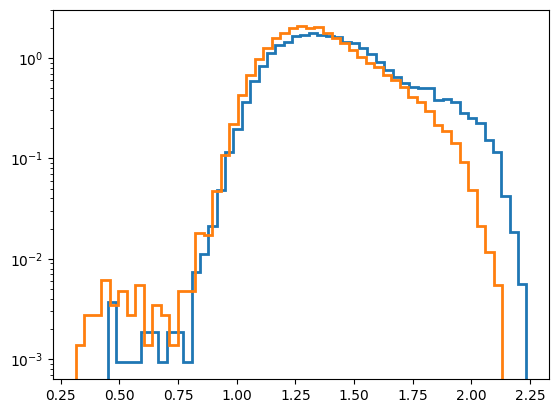

In [26]:
plt.hist(np.log10(energy[boolean][label==1]), bins = 50, histtype='step', density=True, log=True, lw=2)
plt.hist(np.log10(energy[boolean][label==0]), bins = 50, histtype='step', density=True, log=True, lw=2)

Index(['Label', 'EventCounter', 'RecoEnergy', 'CogDistance', 'TotalmDOMCharge',
       'TotalCharge', 'Beta1Reco', 'Beta2Reco', 'Beta3Reco', 'Beta4Reco',
       'Beta5Reco', 'tres_mean', 'tres_std', 'tres_median', 'tres_iqr',
       'tres_sum', 'tres_kurtosis', 'tres_skew', 'dist_mean', 'dist_std',
       'dist_median', 'dist_iqr', 'dist_sum', 'dist_kurtosis', 'dist_skew',
       'ang_mean', 'ang_std', 'ang_median', 'ang_iqr', 'ang_sum',
       'ang_kurtosis', 'ang_skew'],
      dtype='object')